# Checkpoint 2 (Week 3): Data Pipeline + Baseline Model
## FinWise Lending - Credit Risk Project

**Deliverables in this notebook:**
1. Run the full ingestion + preprocessing pipeline (`data_pipeline.py`)
2. Train a **baseline model** — deliberately simple (Logistic Regression),
   so it is fast, interpretable, and sets a floor that any later model
   (e.g. XGBoost) must beat to justify its added complexity.
3. Establish the **evaluation benchmark**: the exact metrics, splits, and
   thresholds every future model will be scored against.
4. Auto-generate the **baseline report** (`baseline_report.md`).

## 1. Setup

In [1]:
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    roc_auc_score, roc_curve, confusion_matrix, classification_report,
    precision_recall_curve, average_precision_score, brier_score_loss
)

from data_pipeline import run_pipeline, TARGET_COLUMN

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("husl")

print("Setup complete.")

Setup complete.


## 2. Run the Data Ingestion + Preprocessing Pipeline

This calls the reusable pipeline in `data_pipeline.py`. The same function
(and the same fitted `preprocessor.pkl`) will be reused unchanged by the
champion model later, so the baseline and champion are compared on
identical data and features — no leakage, no drift between the two.

In [2]:
DATA_PATH = "finwise_loan_applications.csv"  # <-- point this at your real file

pipeline_output = run_pipeline(DATA_PATH, artifacts_dir="artifacts")

X_train, y_train = pipeline_output["X_train"], pipeline_output["y_train"]
X_val, y_val = pipeline_output["X_val"], pipeline_output["y_val"]
X_test, y_test = pipeline_output["X_test"], pipeline_output["y_test"]
preprocessor = pipeline_output["preprocessor"]
ingestion_report = pipeline_output["ingestion_report"]

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
print(f"Features ({len(preprocessor.feature_names_)}): {preprocessor.feature_names_}")

2026-09-11 06:38:02,326 | INFO | Loaded 5,000 rows and 13 columns from finwise_loan_applications.csv


2026-09-11 06:38:02,333 | INFO | Validation complete: 5,000 -> 5,000 rows (0 dropped, 0.0%)


2026-09-11 06:38:02,346 | INFO | Split: train=3,500 (70.0%)  val=500 (10.0%)  test=1,000 (20.0%)


2026-09-11 06:38:02,983 | INFO | Preprocessor fitted on 3,500 rows -> 23 features


2026-09-11 06:38:03,912 | INFO | Preprocessor saved to artifacts/preprocessor.pkl


Train: (3500, 23), Val: (500, 23), Test: (1000, 23)
Features (23): ['age', 'income_annual_inr', 'employment_years', 'existing_loans', 'existing_emi_inr', 'credit_score', 'loan_amount_inr', 'ltv_ratio', 'dti_ratio', 'emi_to_income_ratio', 'loan_to_income_ratio', 'total_debt', 'debt_to_income', 'employment_stability', 'high_dti', 'high_ltv', 'low_credit', 'multiple_loans', 'risk_score', 'employment_type_encoded', 'loan_purpose_encoded', 'credit_score_band_encoded', 'age_group_encoded']


## 3. Data Quality Summary (from ingestion)

In [3]:
print("=" * 60)
print("INGESTION REPORT")
print("=" * 60)
for k, v in ingestion_report.to_dict().items():
    print(f"{k}: {v}")

pct_dropped = (ingestion_report.rows_read - ingestion_report.rows_after_validation) / max(ingestion_report.rows_read, 1)
print(f"\nTotal rows dropped during validation: {pct_dropped:.2%}")

INGESTION REPORT
source: finwise_loan_applications.csv
rows_read: 5000
rows_after_validation: 5000
missing_columns: []
dropped_rows_by_reason: {'null_required_field': 0, 'out_of_range_value': 0}
duplicate_ids_removed: 0

Total rows dropped during validation: 0.00%


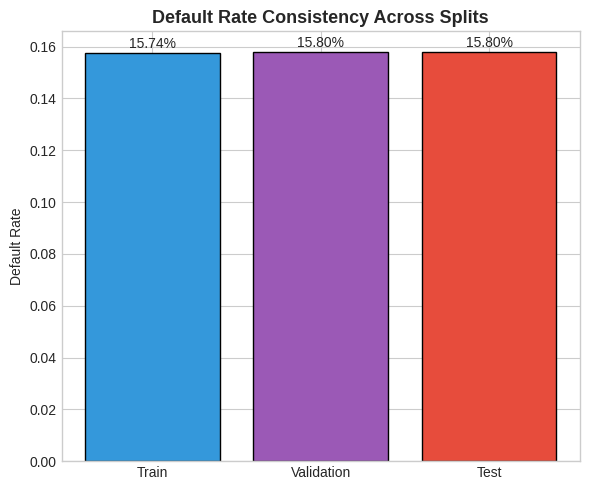

Default rates should be close across splits — a big gap signals a bad split or data drift.


In [4]:
fig, ax = plt.subplots(figsize=(6, 5))
for name, y in [("Train", y_train), ("Validation", y_val), ("Test", y_test)]:
    pass
rates = [y_train.mean(), y_val.mean(), y_test.mean()]
labels = ["Train", "Validation", "Test"]
bars = ax.bar(labels, rates, color=["#3498db", "#9b59b6", "#e74c3c"], edgecolor="black")
for bar, r in zip(bars, rates):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002, f"{r:.2%}", ha="center")
ax.set_ylabel("Default Rate")
ax.set_title("Default Rate Consistency Across Splits", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("split_default_rates.png", dpi=150, bbox_inches="tight")
plt.show()
print("Default rates should be close across splits — a big gap signals a bad split or data drift.")

## 4. Baseline Models

Two baselines, in increasing order of sophistication:
- **Dummy (majority class)**: the "do nothing" floor — predicts the
  training default rate for everyone. Any real model must clearly beat this.
- **Logistic Regression**: the actual baseline model for this checkpoint.
  Chosen because it's fast to train, linear/interpretable (coefficients
  map directly to risk direction), and is the industry-standard starting
  point for credit scoring before reaching for gradient boosting.

In [5]:
# Majority-class dummy baseline
dummy = DummyClassifier(strategy="stratified", random_state=42)
dummy.fit(X_train, y_train)
dummy_val_proba = dummy.predict_proba(X_val)[:, 1]

In [6]:
# Logistic Regression baseline
baseline_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",  # dataset is imbalanced (few defaults)
    random_state=42,
)
baseline_model.fit(X_train, y_train)

train_proba = baseline_model.predict_proba(X_train)[:, 1]
val_proba = baseline_model.predict_proba(X_val)[:, 1]
test_proba = baseline_model.predict_proba(X_test)[:, 1]

print("Baseline Logistic Regression trained.")

Baseline Logistic Regression trained.


## 5. Evaluation Benchmark

This is the fixed set of metrics every future model (including the
champion XGBoost model) will be reported against. Defining it here, on
the baseline, means later comparisons are apples-to-apples.

In [7]:
def gini_from_auc(auc):
    return 2 * auc - 1

def ks_statistic(y_true, y_pred_proba):
    df_ks = pd.DataFrame({"y": y_true, "p": y_pred_proba}).sort_values("p")
    df_ks["cum_good"] = (1 - df_ks["y"]).cumsum() / (1 - df_ks["y"]).sum()
    df_ks["cum_bad"] = df_ks["y"].cumsum() / df_ks["y"].sum()
    return (df_ks["cum_bad"] - df_ks["cum_good"]).abs().max()

def evaluate(y_true, y_pred_proba, threshold=0.5, label=""):
    auc = roc_auc_score(y_true, y_pred_proba)
    gini = gini_from_auc(auc)
    ks = ks_statistic(y_true, y_pred_proba)
    brier = brier_score_loss(y_true, y_pred_proba)
    y_pred = (y_pred_proba >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)

    return {
        "label": label,
        "auc": auc,
        "gini": gini,
        "ks_statistic": ks,
        "brier_score": brier,
        "confusion_matrix": cm.tolist(),
        "n": len(y_true),
        "default_rate": float(np.mean(y_true)),
    }

benchmark = {
    "dummy_val": evaluate(y_val, dummy_val_proba, label="Dummy (majority class)"),
    "baseline_train": evaluate(y_train, train_proba, label="Logistic Regression - Train"),
    "baseline_val": evaluate(y_val, val_proba, label="Logistic Regression - Validation"),
    "baseline_test": evaluate(y_test, test_proba, label="Logistic Regression - Test"),
}

print("=" * 70)
print("EVALUATION BENCHMARK - BASELINE MODEL")
print("=" * 70)
bench_df = pd.DataFrame([
    {"Split": v["label"], "AUC": v["auc"], "Gini": v["gini"],
     "KS": v["ks_statistic"], "Brier": v["brier_score"], "N": v["n"]}
    for v in benchmark.values()
])
print(bench_df.to_string(index=False))

EVALUATION BENCHMARK - BASELINE MODEL
                           Split      AUC     Gini       KS    Brier    N
          Dummy (majority class) 0.504285 0.008569 0.127274 0.272000  500
     Logistic Regression - Train 0.590969 0.181938 0.136328 0.243684 3500
Logistic Regression - Validation 0.624252 0.248504 0.211762 0.245327  500
      Logistic Regression - Test 0.547784 0.095568 0.083827 0.249582 1000


### Acceptance check
The champion model criterion from the project spec is **Gini >= 0.45 on
test**. The baseline is *not* expected to hit that bar — its job is to
set the floor, not the ceiling.

In [8]:
target_gini = 0.45
baseline_test_gini = benchmark["baseline_test"]["gini"]
print(f"Target Gini (test): {target_gini}")
print(f"Baseline Gini (test): {baseline_test_gini:.4f}")
print(f"Gap to close with champion model: {max(0, target_gini - baseline_test_gini):.4f}")

Target Gini (test): 0.45
Baseline Gini (test): 0.0956
Gap to close with champion model: 0.3544


## 6. Benchmark Visuals

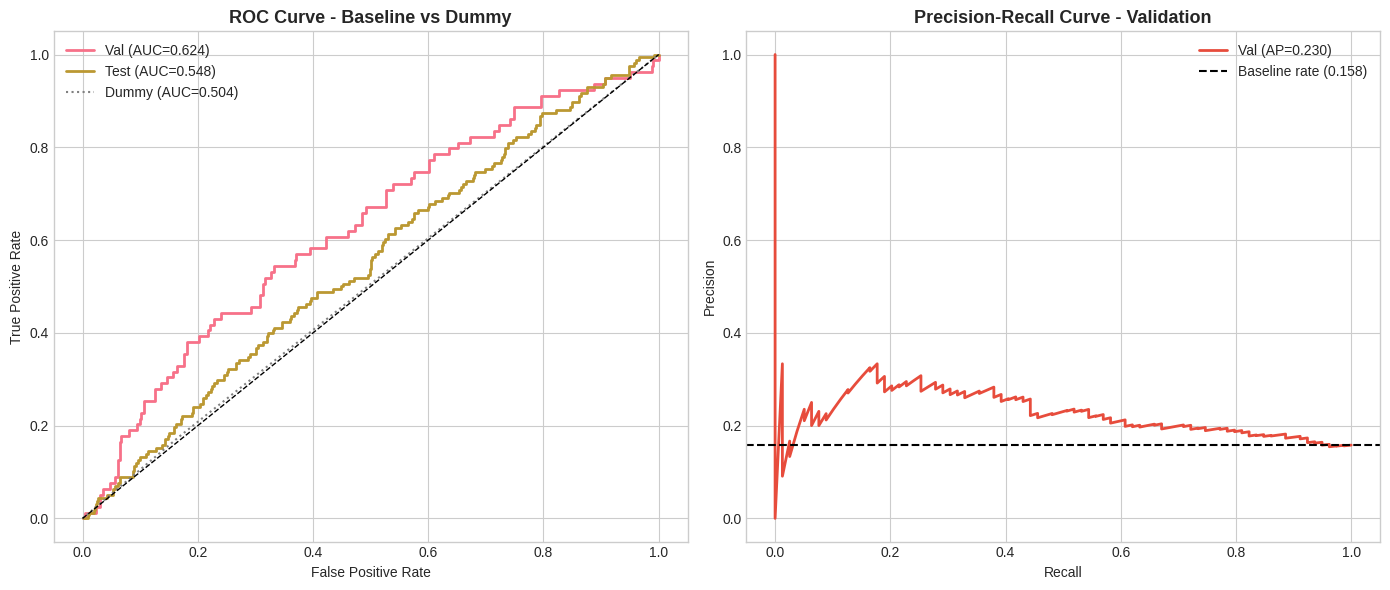

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ROC
ax = axes[0]
fpr_v, tpr_v, _ = roc_curve(y_val, val_proba)
fpr_t, tpr_t, _ = roc_curve(y_test, test_proba)
fpr_d, tpr_d, _ = roc_curve(y_val, dummy_val_proba)
ax.plot(fpr_v, tpr_v, label=f"Val (AUC={benchmark['baseline_val']['auc']:.3f})", linewidth=2)
ax.plot(fpr_t, tpr_t, label=f"Test (AUC={benchmark['baseline_test']['auc']:.3f})", linewidth=2)
ax.plot(fpr_d, tpr_d, label=f"Dummy (AUC={benchmark['dummy_val']['auc']:.3f})", linestyle=":", color="gray")
ax.plot([0, 1], [0, 1], "k--", linewidth=1)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve - Baseline vs Dummy", fontsize=13, fontweight="bold")
ax.legend()

# PR
ax = axes[1]
prec_v, rec_v, _ = precision_recall_curve(y_val, val_proba)
ap_v = average_precision_score(y_val, val_proba)
ax.plot(rec_v, prec_v, label=f"Val (AP={ap_v:.3f})", linewidth=2, color="#e74c3c")
ax.axhline(y_val.mean(), color="k", linestyle="--", label=f"Baseline rate ({y_val.mean():.3f})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve - Validation", fontsize=13, fontweight="bold")
ax.legend()

plt.tight_layout()
plt.savefig("baseline_roc_pr.png", dpi=150, bbox_inches="tight")
plt.show()

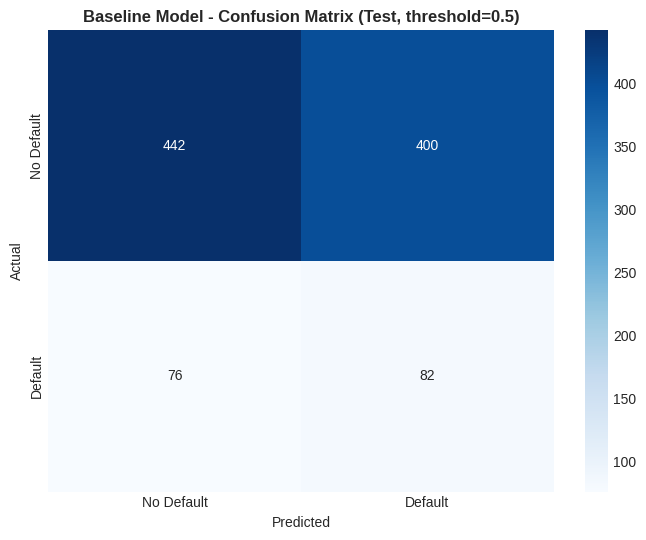

              precision    recall  f1-score   support

  No Default       0.85      0.52      0.65       842
     Default       0.17      0.52      0.26       158

    accuracy                           0.52      1000
   macro avg       0.51      0.52      0.45      1000
weighted avg       0.75      0.52      0.59      1000



In [10]:
fig, ax = plt.subplots(figsize=(7, 5.5))
cm = np.array(benchmark["baseline_test"]["confusion_matrix"])
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=["No Default", "Default"], yticklabels=["No Default", "Default"])
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Baseline Model - Confusion Matrix (Test, threshold=0.5)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("baseline_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

print(classification_report(y_test, (test_proba >= 0.5).astype(int), target_names=["No Default", "Default"]))

## 7. Baseline Feature Directions (coefficients)

Logistic regression coefficients tell us, directionally, which features
push risk up or down — a useful sanity check before moving to a black-box
model like XGBoost.

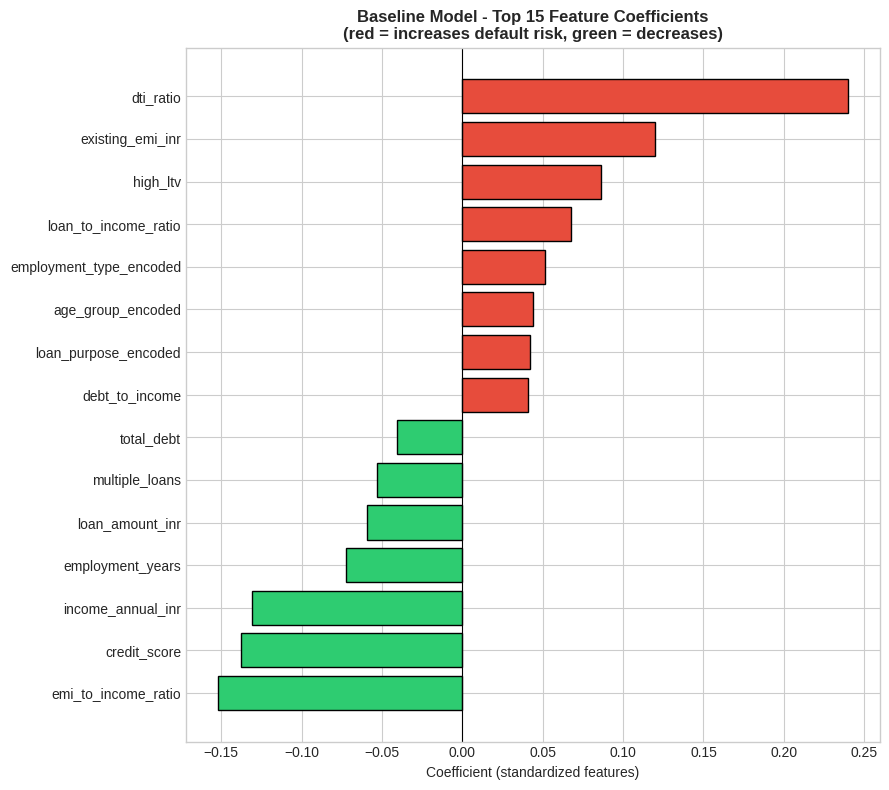

                  feature  coefficient
                dti_ratio     0.240150
      emi_to_income_ratio    -0.152225
             credit_score    -0.137688
        income_annual_inr    -0.130717
         existing_emi_inr     0.119785
                 high_ltv     0.086456
         employment_years    -0.072440
     loan_to_income_ratio     0.067593
          loan_amount_inr    -0.059555
           multiple_loans    -0.053292
  employment_type_encoded     0.051641
        age_group_encoded     0.043774
     loan_purpose_encoded     0.042140
               total_debt    -0.040823
           debt_to_income     0.040797
           existing_loans     0.033108
                ltv_ratio     0.032659
                 high_dti    -0.024256
                      age     0.018610
     employment_stability     0.015816
credit_score_band_encoded    -0.002579
               risk_score     0.001828
               low_credit    -0.000263


In [11]:
coef_df = pd.DataFrame({
    "feature": X_train.columns,
    "coefficient": baseline_model.coef_[0]
}).sort_values("coefficient", key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(9, 8))
top_coef = coef_df.head(15).sort_values("coefficient")
colors = ["#e74c3c" if c > 0 else "#2ecc71" for c in top_coef["coefficient"]]
ax.barh(top_coef["feature"], top_coef["coefficient"], color=colors, edgecolor="black")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Coefficient (standardized features)")
ax.set_title("Baseline Model - Top 15 Feature Coefficients\n(red = increases default risk, green = decreases)",
              fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("baseline_coefficients.png", dpi=150, bbox_inches="tight")
plt.show()

print(coef_df.to_string(index=False))

## 8. Save Benchmark Artifacts

In [12]:
Path("artifacts").mkdir(exist_ok=True)

import pickle
with open("artifacts/baseline_model.pkl", "wb") as f:
    pickle.dump(baseline_model, f)

benchmark_export = {k: {kk: vv for kk, vv in v.items()} for k, v in benchmark.items()}
with open("artifacts/evaluation_benchmark.json", "w") as f:
    json.dump(benchmark_export, f, indent=2, default=str)

coef_df.to_csv("artifacts/baseline_coefficients.csv", index=False)

print("Saved: artifacts/baseline_model.pkl")
print("Saved: artifacts/evaluation_benchmark.json  <- future models compare against this")
print("Saved: artifacts/baseline_coefficients.csv")

Saved: artifacts/baseline_model.pkl
Saved: artifacts/evaluation_benchmark.json  <- future models compare against this
Saved: artifacts/baseline_coefficients.csv


## 9. Auto-Generate the Baseline Report

In [13]:
report_md = f"""# FinWise Lending — Baseline Report
## Checkpoint 2 (Week 3): Data Pipeline + Baseline Model

**Status:** Complete
**Model:** Logistic Regression (class-balanced)
**Purpose:** Establish the data pipeline and the performance floor that any
later model (e.g. the XGBoost champion model) must clearly exceed.

---

## 1. Data Pipeline Summary

- **Source file:** `{DATA_PATH}`
- **Rows ingested:** {ingestion_report.rows_read:,}
- **Rows after validation:** {ingestion_report.rows_after_validation:,}
  ({(ingestion_report.rows_read - ingestion_report.rows_after_validation) / max(ingestion_report.rows_read,1):.2%} dropped)
- **Duplicate application IDs removed:** {ingestion_report.duplicate_ids_removed}
- **Rows dropped for missing required fields:** {ingestion_report.dropped_rows_by_reason.get('null_required_field', 0)}
- **Rows dropped for out-of-range values:** {ingestion_report.dropped_rows_by_reason.get('out_of_range_value', 0)}

**Pipeline stages:** ingest -> validate schema -> clean rows -> engineer
features -> stratified train/val/test split -> fit preprocessor on train
only -> transform all splits.

**Split sizes:**

| Split | Rows | Default Rate |
|---|---|---|
| Train | {len(y_train):,} | {y_train.mean():.2%} |
| Validation | {len(y_val):,} | {y_val.mean():.2%} |
| Test | {len(y_test):,} | {y_test.mean():.2%} |

**Features used ({len(preprocessor.feature_names_)}):** {', '.join(preprocessor.feature_names_)}

---

## 2. Baseline Model

- **Algorithm:** Logistic Regression, `class_weight="balanced"`, `max_iter=1000`
- **Why this baseline:** fast, interpretable via coefficients, and the
  standard industry starting point for credit scoring before reaching for
  gradient boosting. It gives a defensible floor: any added model
  complexity later must be justified by a clear lift over these numbers.

---

## 3. Evaluation Benchmark

This is the fixed benchmark all future models are compared against.

| Split | AUC | Gini | KS Statistic | Brier Score |
|---|---|---|---|---|
| Dummy (majority class), Val | {benchmark['dummy_val']['auc']:.4f} | {benchmark['dummy_val']['gini']:.4f} | {benchmark['dummy_val']['ks_statistic']:.4f} | {benchmark['dummy_val']['brier_score']:.4f} |
| Baseline, Train | {benchmark['baseline_train']['auc']:.4f} | {benchmark['baseline_train']['gini']:.4f} | {benchmark['baseline_train']['ks_statistic']:.4f} | {benchmark['baseline_train']['brier_score']:.4f} |
| Baseline, Validation | {benchmark['baseline_val']['auc']:.4f} | {benchmark['baseline_val']['gini']:.4f} | {benchmark['baseline_val']['ks_statistic']:.4f} | {benchmark['baseline_val']['brier_score']:.4f} |
| Baseline, Test | {benchmark['baseline_test']['auc']:.4f} | {benchmark['baseline_test']['gini']:.4f} | {benchmark['baseline_test']['ks_statistic']:.4f} | {benchmark['baseline_test']['brier_score']:.4f} |

**Project target (champion model):** Gini >= 0.45 on test.
**Baseline Gini on test:** {baseline_test_gini:.4f}
**Gap remaining for the champion model to close:** {max(0, target_gini - baseline_test_gini):.4f}

The baseline is not expected to meet the champion-model target — its role
is to prove the pipeline works end-to-end and to give a numeric floor
("beat this or the added complexity isn't worth it").

---

## 4. Top Risk Directions (Baseline Coefficients)

Top absolute-value coefficients from the baseline model, on standardized
features (positive = increases default risk):

{coef_df.head(10).to_markdown(index=False)}

---

## 5. Known Limitations of the Baseline

1. Logistic Regression assumes linear/additive relationships — it will
   miss interaction effects (e.g. high DTI *combined with* low tenure)
   that a tree-based model can capture.
2. No hyperparameter tuning was performed — this is intentionally a
   floor, not an optimized model.
3. Bias/fairness audit is deferred to the champion-model checkpoint.
4. Calibration was not explicitly tuned; `class_weight="balanced"` trades
   calibration for better separation on the minority (default) class.

## 6. Next Steps (Checkpoint 3)

- Train the champion model (XGBoost) using the **same** `data_pipeline.py`
  and `preprocessor.pkl` produced here, so the comparison is apples-to-apples.
- Compare champion vs. baseline on this exact benchmark table.
- Run the full SHAP explainability and bias-audit workstreams on the
  champion model.
"""

with open("artifacts/baseline_report.md", "w") as f:
    f.write(report_md)

print("Baseline report saved to artifacts/baseline_report.md")
print("\n" + "=" * 70)
print("CHECKPOINT 2 COMPLETE")
print("=" * 70)
print("- Data pipeline: data_pipeline.py")
print("- Fitted preprocessor: artifacts/preprocessor.pkl")
print("- Baseline model: artifacts/baseline_model.pkl")
print("- Evaluation benchmark: artifacts/evaluation_benchmark.json")
print("- Baseline report: artifacts/baseline_report.md")

Baseline report saved to artifacts/baseline_report.md

CHECKPOINT 2 COMPLETE
- Data pipeline: data_pipeline.py
- Fitted preprocessor: artifacts/preprocessor.pkl
- Baseline model: artifacts/baseline_model.pkl
- Evaluation benchmark: artifacts/evaluation_benchmark.json
- Baseline report: artifacts/baseline_report.md
